Poissonov problem $\\$
$-\Delta u = f$ na $(0,1)^2$ $\\$
$u=0$ na $\partial[0,1]^2$

In [1]:
from ngsolve import *
from ngsolve.webgui import Draw

import scipy.sparse as sp
from scipy.sparse import csr_matrix
import matplotlib.pylab as plt

In [2]:
mesh = Mesh(unit_square.GenerateMesh(maxh=0.01))
Draw (mesh);

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

In [3]:
fes = H1(mesh, order=1, dirichlet="left|right|bottom|top")
print ("ndof =", fes.ndof)

ndof = 11808


In [4]:
print (mesh.GetBoundaries())

('bottom', 'right', 'top', 'left')


In [5]:
u = fes.TrialFunction()
v = fes.TestFunction()

f = LinearForm(fes)
f += 32*(y*(1-y)+x*(1-x))*v*dx

a = BilinearForm(fes)
a += InnerProduct(grad(u), grad(v)) * dx

a.Assemble()
f.Assemble()

In [6]:
n = a.mat.height
density = a.mat.nze / (n*n)
print("Ukupan broj elemenata:", n*n)
print("Broj nenul elemenata:", a.mat.nze)
print("Popunjenost:", density)

Ukupan broj elemenata: 139428864
Broj nenul elemenata: 81850
Popunjenost: 0.000587037702609411


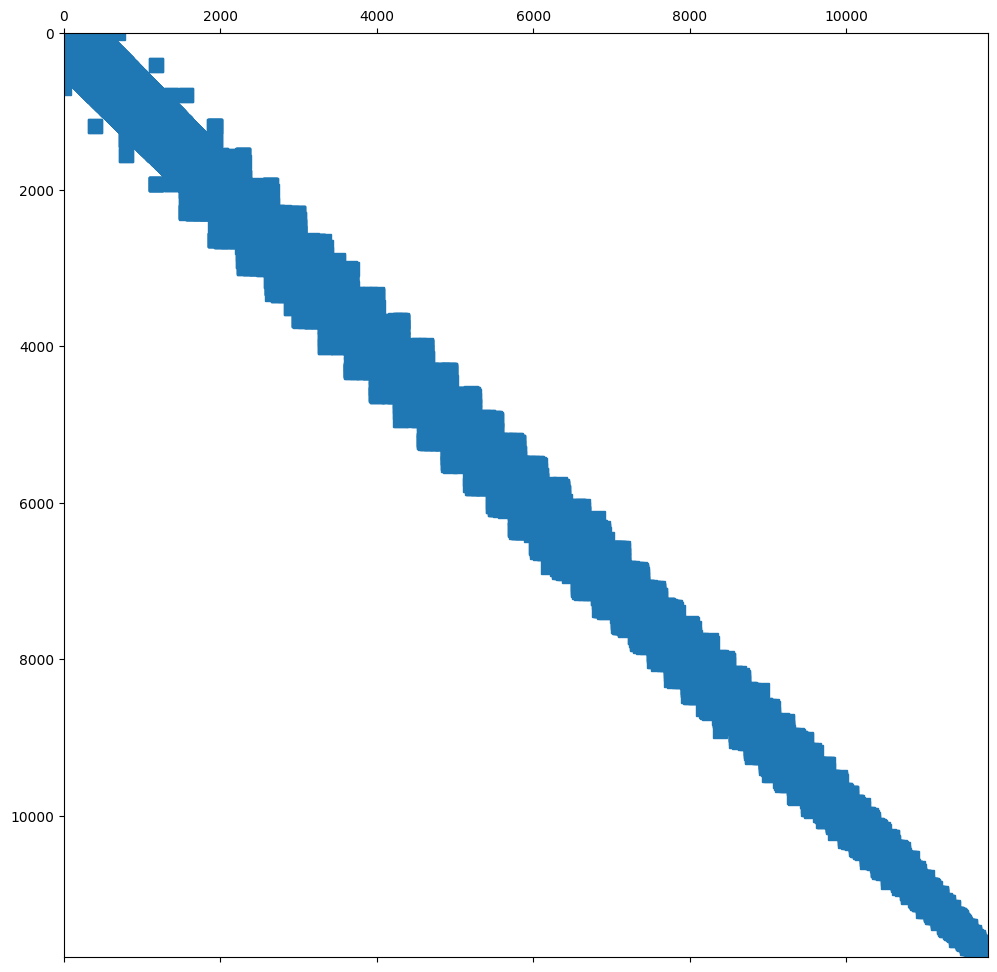

In [7]:
plt.rcParams['figure.figsize'] = (12, 12)
A = sp.csr_matrix(a.mat.CSR())

plt.spy(A)
plt.show()

In [8]:
print (csr_matrix(a.mat.CSR()))

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 81850 stored elements and shape (11808, 11808)>
  Coords	Values
  (0, 0)	1.0000000000000182
  (0, 4)	-0.5000000000000203
  (0, 399)	-0.4999999999999979
  (1, 1)	0.8502590538608931
  (1, 102)	-0.3009810630780792
  (1, 103)	-0.3001967822198601
  (1, 498)	-0.24908120856295374
  (2, 2)	0.9999999999999999
  (2, 201)	-0.49999999999999994
  (2, 202)	-0.49999999999999994
  (3, 3)	0.8503747532174388
  (3, 300)	-0.3012348402272472
  (3, 301)	-0.30046868626416623
  (3, 695)	-0.24867122672602526
  (4, 0)	-0.5000000000000203
  (4, 4)	1.8959042060241815
  (4, 5)	-0.5199548745365247
  (4, 399)	-0.15874623736444948
  (4, 400)	-0.7172030941231873
  (5, 4)	-0.5199548745365247
  (5, 5)	1.8751758262024518
  (5, 6)	-0.33279477505785704
  (5, 400)	-0.20440355574555902
  (5, 401)	-0.8180226208625109
  (6, 5)	-0.33279477505785704
  :	:
  (11804, 11804)	3.5521354810333774
  (11804, 11805)	-0.4766995322495712
  (11804, 11807)	-0.8485326940201035
  (1

In [9]:
solution_gf = GridFunction(fes)
solution_gf.vec.data = a.mat.Inverse(fes.FreeDofs()) * f.vec

In [10]:
Draw (solution_gf, mesh, deformation=True, scale=0.5)

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

BaseWebGuiScene

Tok $q$ dan je izrazom $q=-\nabla{u}$, gdje $u$ predstavlja rješenje problema.

In [11]:
Draw (-grad(solution_gf), mesh, "Flux", vectors= { "grid_size" : 40});

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

In [12]:
exact_cf = 16*x*(1-x)*y*(1-y)

error_L2 = sqrt(Integrate((solution_gf - exact_cf)**2, mesh))
print ("L2 norm error:", error_L2)

L2 norm error: 7.66047740242973e-05


In [13]:
exact_grad_cf_x = exact_cf.Diff(x)
exact_grad_cf_y = exact_cf.Diff(y)

exact_grad_cf = CF((exact_grad_cf_x, exact_grad_cf_y))

error_H1_semi = sqrt(Integrate((grad(solution_gf) - exact_grad_cf)**2, mesh))
print ("H1 seminorm error:", error_H1_semi)

H1 seminorm error: 0.027936644733002797


In [14]:
error_H1 = sqrt(error_L2**2 + error_H1_semi**2)
print ("H1 norm error:", error_H1)

H1 norm error: 0.02793674976137017
